In [8]:
from utils.utils import *
import matplotlib.pyplot as plt

In [4]:
data = load_saved_data("data_with_spikes")

In [5]:
def build_stimulus_table(session):
    n_time = len(session["t"])

    stim_df = pd.DataFrame(index=np.arange(n_time))
    stim_df["stimulus"] = "none"

    # ---------- drifting gratings ----------
    if "drifting_gratings" in session["stim_tables"]:

        stim_df["orientation"] = np.nan
        stim_df["temporal_frequency"] = np.nan
        stim_df["blank"] = False

        table = session["stim_tables"]["drifting_gratings"]

        for _, row in table.iterrows():
            idx = slice(int(row.start), int(row.end))

            stim_df.loc[idx, "stimulus"] = "drifting_gratings"
            stim_df.loc[idx, "orientation"] = row.orientation
            stim_df.loc[idx, "temporal_frequency"] = row.temporal_frequency
            stim_df.loc[idx, "blank"] = bool(row.blank_sweep)

    # ---------- static gratings ----------
    if "static_gratings" in session["stim_tables"]:

        stim_df["orientation"] = np.nan
        stim_df["spatial_frequency"] = np.nan
        stim_df["phase"] = np.nan

        table = session["stim_tables"]["static_gratings"]

        for _, row in table.iterrows():
            idx = slice(int(row.start), int(row.end))

            stim_df.loc[idx, "stimulus"] = "static_gratings"
            stim_df.loc[idx, "orientation"] = row.orientation
            stim_df.loc[idx, "spatial_frequency"] = row.spatial_frequency
            stim_df.loc[idx, "phase"] = row.phase

    # ---------- natural scenes ----------
    if "natural_scenes" in session["stim_tables"]:

        stim_df["frame"] = -1

        table = session["stim_tables"]["natural_scenes"]

        for _, row in table.iterrows():
            idx = slice(int(row.start), int(row.end))

            stim_df.loc[idx, "stimulus"] = "natural_scenes"
            stim_df.loc[idx, "frame"] = int(row.frame)

    # ---------- sparse noise ----------
    if "locally_sparse_noise" in session["stim_tables"]:

        stim_df["frame"] = -1

        table = session["stim_tables"]["locally_sparse_noise"]

        for _, row in table.iterrows():
            idx = slice(int(row.start), int(row.end))

            stim_df.loc[idx, "stimulus"] = "locally_sparse_noise"
            stim_df.loc[idx, "frame"] = int(row.frame)

    return stim_df


In [6]:
def to_frame_aligned_running(session):
    speed = session["running_speed"][0]
    time = session["running_speed"][1]

    # since dt matches, this is basically identity mapping
    t = session["t"]

    aligned = np.interp(t, time, speed)

    return aligned

In [7]:
reduced = {}

for name, session in data["sessions"].items():
    session["running_aligned"] = to_frame_aligned_running(session)
    reduced[name] = {
        "t": session["t"],
        "spikes": session["spikes"],
        "running_speed": session["running_aligned"],
        "stimulus": build_stimulus_table(session),
    }

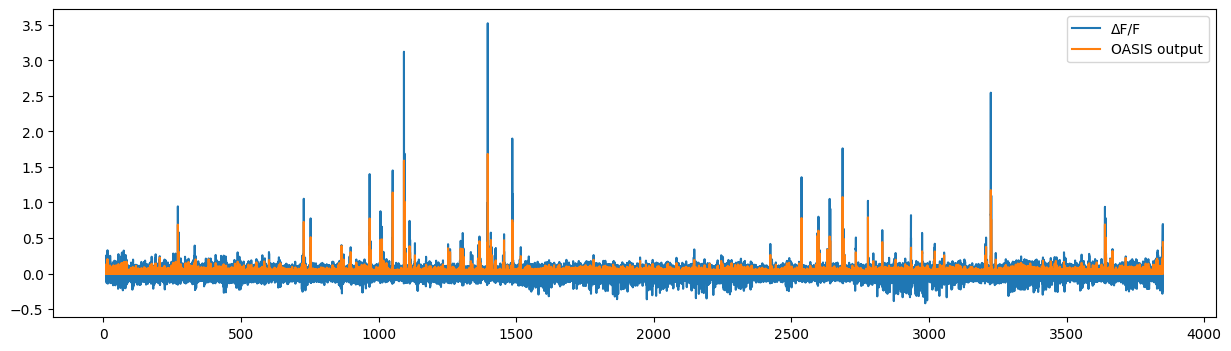

In [9]:
plt.figure(figsize=(15, 4))

plt.plot(session["t"], session["dff"][0], label="ΔF/F")
plt.plot(session["t"], session["spikes"][0], label="OASIS output")

plt.legend()

In [10]:
def plot_trial(
        data,
        session_name="A",
        cell=0,
        trial=0,
        padding=2.0,
):
    """
    Plot one stimulus presentation with padding before/after.

    Parameters
    ----------
    session_name : "A","B","C"
    cell : int
        Neuron index.
    trial : int
        Row of the stimulus table.
    padding : float
        Seconds before and after stimulus.
    """

    session = data["sessions"][session_name]

    # ------------------------------
    # determine which stimulus table exists
    # ------------------------------
    stim_name = list(session["stim_tables"].keys())[0]
    stim_table = session["stim_tables"][stim_name]

    row = stim_table.iloc[trial]

    stim_start = float(row.start)
    stim_end = float(row.end)

    t0 = stim_start - padding
    t1 = stim_end + padding

    # ------------------------------
    # calcium imaging time
    # ------------------------------
    t = session["t"]
    mask = (t >= t0) & (t <= t1)

    # ------------------------------
    # running time
    # ------------------------------
    running_speed = session["running_speed"][0]
    running_time = session["running_speed"][1]

    mask_run = (running_time >= t0) & (running_time <= t1)

    # ------------------------------
    # figure
    # ------------------------------
    fig, ax = plt.subplots(
        5,
        1,
        figsize=(14, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [0.5, 1, 2, 2, 1]},
    )

    # ==========================================================
    # stimulus
    # ==========================================================

    ax[0].axvspan(
        stim_start,
        stim_end,
        color="tab:blue",
        alpha=0.35,
    )

    if stim_name == "drifting_gratings":
        label = (
            f"{row.orientation:.0f}°\n"
            f"TF={row.temporal_frequency:.0f}"
        )

        if bool(row.blank_sweep):
            label = "Blank"

    elif stim_name == "static_gratings":
        label = (
            f"{row.orientation:.0f}°\n"
            f"SF={row.spatial_frequency}\n"
            f"phase={row.phase}"
        )

    elif stim_name == "natural_scenes":
        label = f"Scene {int(row.frame)}"

    elif stim_name == "locally_sparse_noise":
        label = f"Noise {int(row.frame)}"

    else:
        label = stim_name

    ax[0].text(
        (stim_start + stim_end) / 2,
        0.5,
        label,
        ha="center",
        va="center",
        fontsize=10,
    )

    ax[0].set_ylim(0, 1)
    ax[0].set_yticks([])
    ax[0].set_ylabel("Stim")

    # ==========================================================
    # running
    # ==========================================================

    ax[1].plot(
        running_time[mask_run],
        running_speed[mask_run],
        color="black",
    )

    ax[1].set_ylabel("cm/s")

    # ==========================================================
    # fluorescence
    # ==========================================================

    ax[2].plot(
        t[mask],
        session["dff"][cell, mask],
        color="forestgreen",
        lw=1,
    )

    ax[2].set_ylabel("ΔF/F")

    # ==========================================================
    # OASIS calcium fit
    # ==========================================================

    ax[3].plot(
        t[mask],
        session["calcium_fit"][cell, mask],
        color="tab:red",
        lw=1,
    )

    ax[3].set_ylabel("Fit")

    # ==========================================================
    # inferred spikes
    # ==========================================================

    ax[4].stem(
        t[mask],
        session["spikes"][cell, mask],
        linefmt="k-",
        markerfmt=" ",
        basefmt=" ",
    )

    ax[4].set_ylabel("Spikes")
    ax[4].set_xlabel("Time (s)")

    # ------------------------------
    # identical limits for all panels
    # ------------------------------
    for a in ax:
        a.set_xlim(t0, t1)

        # show stimulus onset/offset everywhere
        a.axvline(stim_start, color="dodgerblue", ls="--", lw=1)
        a.axvline(stim_end, color="dodgerblue", ls="--", lw=1)

    plt.suptitle(
        f"Session {session_name} | Cell {cell} | "
        f"{stim_name} | Trial {trial}"
    )

    plt.tight_layout()

    return fig

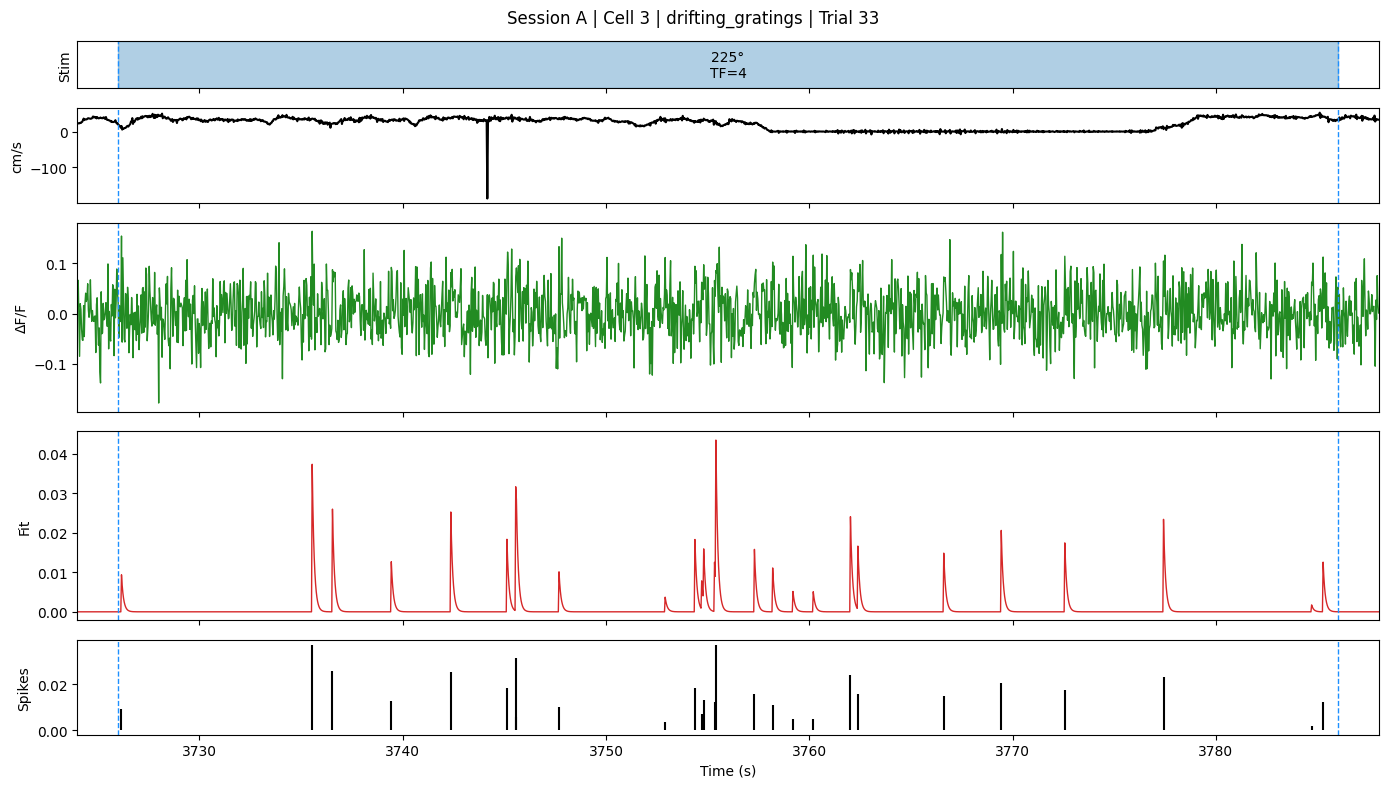

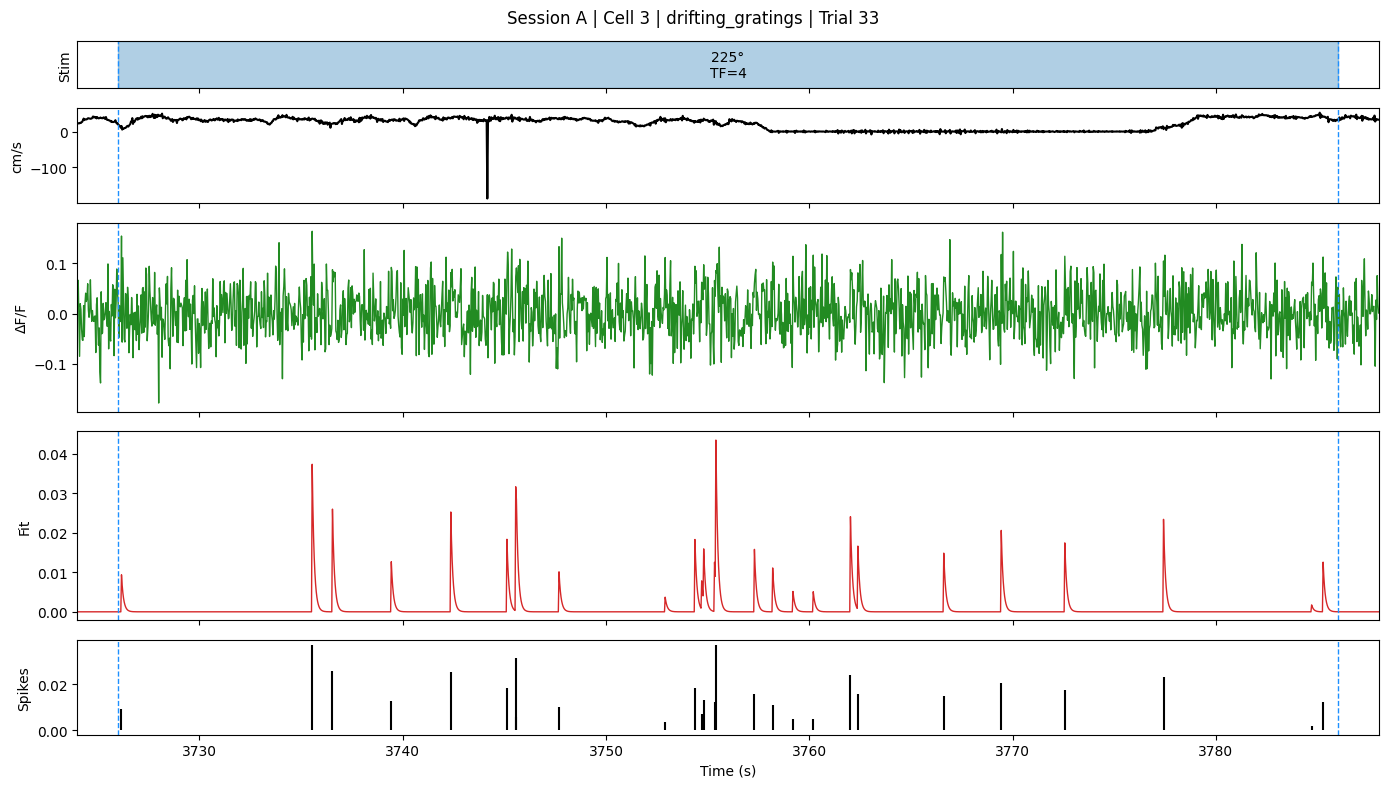

In [11]:
plot_trial(
    data,
    session_name="A",
    cell=3,
    trial=33,
    padding=2,
)